# Importing and Querying Data with PostgreSQL (Northwind Database)

Describtion of the Northwind Database: https://en.wikiversity.org/wiki/Database_Examples/Northwind 

Example SQL-Queries based on the Northwind Database: https://www.w3schools.com/sql/default.asp

SQL Tutorials: https://www.youtube.com/watch?v=zpnHsWOy0RY&list=PLP9IO4UYNF0UQkBXlTMSw0CYsxv-GDkkI

## Frequently used SQL clauses (for in-depth learning)

<div>
  <style>
    .sql-keyword {
      color: white;
    }
  </style>
  <span class="sql-keyword">SELECT</span><br>
  <span class="sql-keyword">SELECT DISTINCT</span><br>
  <span class="sql-keyword">FROM</span><br>
  <span class="sql-keyword">WHERE</span><br>
  <span class="sql-keyword">AND</span><br>
  <span class="sql-keyword">LIKE</span><br>
  <span class="sql-keyword">GROUP BY</span><br>
  <span class="sql-keyword">HAVING</span><br>
  <span class="sql-keyword">ORDER BY</span><br>
  <span class="sql-keyword">FULL JOIN</span><br>
  <span class="sql-keyword">INNER JOIN</span><br>
  <span class="sql-keyword">LEFT JOIN</span><br>
  <span class="sql-keyword">RIGHT JOIN</span><br>
  <span class="sql-keyword">ON</span><br>
  <span class="sql-keyword">LIMIT</span><br>
  <span class="sql-keyword">AS</span><br>
  <span class="sql-keyword">AVG</span><br>
  <span class="sql-keyword">COUNT</span><br>
  <span class="sql-keyword">MIN</span><br>
  <span class="sql-keyword">MAX</span><br>
  <span class="sql-keyword">SUM</span><br>
  <span class="sql-keyword">BETWEEN</span><br>
  <span class="sql-keyword">IN</span><br>
  <span class="sql-keyword">IS NULL</span><br>
  <span class="sql-keyword">IS NOT NULL</span><br> 
  <span class="sql-keyword">ROUND</span><br> 
  <span class="sql-keyword">CAST</span><br>
  <span class="sql-keyword">NUMERIC</span><br>
  <span class="sql-keyword">INTEGER</span>  
</div>

## Libraries and Settings

In [3]:
# Libraries
import os
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt

# Settings
import warnings
warnings.filterwarnings("ignore")

# Dark background style for all graphics 
plt.style.use('dark_background')

# Current working directory
print(os.getcwd())

/Users/simonschmid/Documents/Repositories/python_postgresql_pgadmin


## Read data from .csv files to separate data frames 

In [4]:
# Define path to data
path = os.path.join(os.getcwd(), 'Data/')

# Read data from .csv files
df_categroies = pd.read_csv(f'{path}Categories.csv', sep=',')
df_customers = pd.read_csv(f'{path}Customers.csv', sep=',')
df_categories = pd.read_csv(f'{path}Categories.csv', sep=',')
df_employees = pd.read_csv(f'{path}Employees.csv', sep=',')
df_order_details = pd.read_csv(f'{path}OrderDetails.csv', sep=',')
df_orders = pd.read_csv(f'{path}Orders.csv', sep=',')
df_products = pd.read_csv(f'{path}Products.csv', sep=',')
df_shippers = pd.read_csv(f'{path}Shippers.csv', sep=',')
df_suppliers = pd.read_csv(f'{path}Suppliers.csv', sep=',')

# Change column names to lowercase
df_customers.columns = df_customers.columns.str.lower()
df_categories.columns = df_categories.columns.str.lower()
df_employees.columns = df_employees.columns.str.lower()
df_order_details.columns = df_order_details.columns.str.lower()
df_orders.columns = df_orders.columns.str.lower()
df_products.columns = df_products.columns.str.lower()
df_shippers.columns = df_shippers.columns.str.lower()
df_suppliers.columns = df_suppliers.columns.str.lower()

# Check dimensions of DataFrames
print("Dimensions of DataFrames:")
print(f"Customers: {df_customers.shape}")
print(f"Categories: {df_categories.shape}")
print(f"Employees: {df_employees.shape}")
print(f"Order Details: {df_order_details.shape}")
print(f"Orders: {df_orders.shape}")
print(f"Products: {df_products.shape}")
print(f"Shippers: {df_shippers.shape}")
print(f"Suppliers: {df_suppliers.shape}")

Dimensions of DataFrames:
Customers: (91, 7)
Categories: (8, 3)
Employees: (10, 6)
Order Details: (518, 4)
Orders: (196, 5)
Products: (77, 6)
Shippers: (3, 3)
Suppliers: (29, 8)


## Create database connection

In [5]:
# Set up database connection
user = "pgadmin"
password = "geheim"
host = "localhost"
port = "5432"
database = "northwind"

# Create Connection URL
db_connection_url = "postgresql://" + user + ":" + password +\
                    "@" + host + ":" + port + "/" + database

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Test database connection
with engine.connect() as connection:
    result = connection.execute(text('SELECT current_database()'))
    print(result.fetchone())

# Dispose the engine
engine.dispose()

('northwind',)


## Write data frames to database tables

In [6]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Drop tables if it exist
with engine.connect() as connection:
    connection.execute(text("DROP TABLE IF EXISTS public.categories CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.customers CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.employees CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.orderdetails CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.orders CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.products CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.shippers CASCADE;"))
    connection.execute(text("DROP TABLE IF EXISTS public.suppliers CASCADE;"))
    connection.commit()

# CASCADE: löscht automatiisch alle abhängigen Objekte, wie z.B. Fremdschlüsselbeziehungen, die auf die Tabelle verweisen.

# Write DataFrames to database
df_categories.to_sql('categories', engine)
df_customers.to_sql('customers', engine)
df_employees.to_sql('employees', engine)
df_order_details.to_sql('orderdetails', engine)
df_orders.to_sql('orders', engine)
df_products.to_sql('products', engine)
df_shippers.to_sql('shippers', engine)
df_suppliers.to_sql('suppliers', engine)

# Dispose the engine
engine.dispose()

## List tables in the database

In [7]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Open a connection
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT table_name
                                        FROM information_schema.tables
                                        WHERE table_schema = 'public'"""))
    
    # Fetch and print the results
    for row in result:
        print(row[0])

# Dispose the engine
engine.dispose()

categories
customers
employees
orderdetails
orders
products
shippers
suppliers


## Create a SQL query to retrieve product information from a database.

In [8]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''SELECT * FROM products''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub.head(5)

,index,productid,productname,supplierid,categoryid,unit,price
0,0,1,Chais,1,1,10 boxes x 20 bags,18.00
1,1,2,Chang,1,1,24 - 12 oz bottles,19.00
2,2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00
3,3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00
4,4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35


## Plot product prices

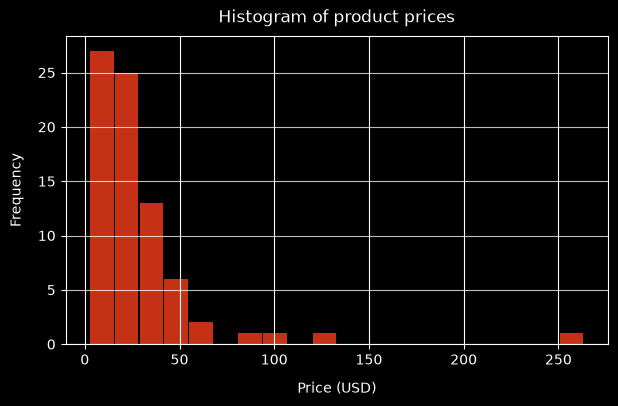

In [9]:
# Plot Histogram
fig = plt.figure( figsize=(7,4))
plt.xticks(fontsize=14, rotation=0)
plt.yticks(fontsize=14, rotation=0)
n, bins, patches = plt.hist(x=df_sub['price'], 
                            bins=20, 
                            color='#C53115',
                            alpha=1.00, 
                            rwidth=0.95
                   )
plt.grid(True)
plt.ticklabel_format(style='plain')
plt.grid(axis='y', alpha=0.75)

# Set labels
plt.xlabel('Price (USD)', fontsize=10, labelpad=10)
plt.ylabel('Frequency', fontsize=10, labelpad=10)
plt.title('Histogram of product prices', fontsize=12, pad=10)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [10]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.6.0
Datetime: 2026-09-19 11:19:44
Python Version: 3.14.7
-----------------------------------


# QUESTIONS

In [11]:
engine = create_engine(db_connection_url)

1. What are the details of all customers whose country is 'Spain'?

In [12]:
with engine.connect() as connection:

# Execute the query
    result = connection.execute(text("""SELECT * FROM customers WHERE country = 'Spain'"""))

    # Fetch and print the results
    for row in result.fetchmany(5):
        print(row)

(7, 8, 'Bólido Comidas preparadas', 'Martín Sommer', 'C/ Araquil, 67', 'Madrid', '28023', 'Spain')
(21, 22, 'FISSA Fabrica Inter. Salchichas S.A.', 'Diego Roel', 'C/ Moralzarzal, 86', 'Madrid', '28034', 'Spain')
(28, 29, 'Galería del gastrónomo', 'Eduardo Saavedra', 'Rambla de Cataluña, 23', 'Barcelona', '8022', 'Spain')
(29, 30, 'Godos Cocina Típica', 'José Pedro Freyre', 'C/ Romero, 33', 'Sevilla', '41101', 'Spain')
(68, 69, 'Romero y tomillo', 'Alejandra Camino', 'Gran Vía, 1', 'Madrid', '28001', 'Spain')


2. What are the distinct cities of customers from Germany with a city containing the letter 'B'?

In [13]:
# Open a connection
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT DISTINCT City FROM customers WHERE country = 'Germany' AND city LIKE '%B%'"""))
    
    # Fetch and print the results
    for row in result.fetchmany(5):
        print(row[0])

Berlin
Brandenburg


3. What are the number of orders placed by each customer? Sort the result by the number of orders in descending order.

In [14]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    CustomerID, 
    COUNT(OrderID) AS OrderCount
    FROM Orders
    GROUP BY CustomerID
    ORDER BY OrderCount DESC;"""))
    
    # Fetch and print the results
    for row in result.fetchmany(5):
        print(row)

(20, 10)
(65, 7)
(63, 7)
(87, 7)
(37, 6)


4. What are the customers who have placed more than 3 orders?

In [15]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    CustomerID, 
    COUNT(OrderID) AS OrderCount
    FROM Orders
    GROUP BY CustomerID
    HAVING COUNT(OrderID) > 3;"""))
    
    # Fetch and print the results
    for row in result.fetchmany(5):
        print(row)

(87, 7)
(71, 4)
(51, 5)
(80, 4)
(65, 7)


5. What are the top 5 most expensive products? Round the price to 2 decimal places.

In [ ]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    ProductName, 
    ROUND(CAST(Price AS NUMERIC), 2) AS Price
    FROM Products
    ORDER BY Price DESC
    IMIT 5;"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

('Côte de Blaye', 263.5)
('Thüringer Rostbratwurst', 123.79)
('Mishi Kobe Niku', 97.0)
("Sir Rodney's Marmalade", 81.0)
('Carnarvon Tigers', 62.5)


6. What are the order details (ProductID, Quantity) for customers from France?

In [25]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
	o.OrderID, 
	c.CustomerName, 
	c.Country, 
	od.ProductID, 
	od.Quantity
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN OrderDetails od ON o.OrderID = od.OrderID
    WHERE c.Country = 'France';"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

(10251, 'Victuailles en stock', 'France', 22, 6)
(10251, 'Victuailles en stock', 'France', 57, 15)
(10251, 'Victuailles en stock', 'France', 65, 20)
(10265, 'Blondel père et fils', 'France', 17, 30)
(10265, 'Blondel père et fils', 'France', 70, 20)
(10274, 'Vins et alcools Chevalier', 'France', 71, 20)
(10274, 'Vins et alcools Chevalier', 'France', 72, 7)
(10295, 'Vins et alcools Chevalier', 'France', 56, 4)
(10297, 'Blondel père et fils', 'France', 39, 60)
(10297, 'Blondel père et fils', 'France', 72, 20)
(10311, 'Du monde entier', 'France', 42, 6)
(10311, 'Du monde entier', 'France', 69, 7)
(10331, "Bon app''", 'France', 54, 15)
(10334, 'Victuailles en stock', 'France', 52, 8)
(10334, 'Victuailles en stock', 'France', 68, 10)
(10340, "Bon app''", 'France', 18, 20)
(10340, "Bon app''", 'France', 41, 12)
(10340, "Bon app''", 'France', 43, 40)
(10350, "La maison d''Asie", 'France', 50, 15)
(10350, "La maison d''Asie", 'France', 69, 18)
(10358, "La maison d''Asie", 'France', 24, 10)
(103

7. Area there products without a category assigned?

In [ ]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    ProductID, 
    ProductName,
    CategoryID
    FROM Products
    WHERE CategoryID IS NULL;"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

8. What are all orders and their employees?

In [34]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    *
    FROM Orders o
    LEFT JOIN Employees c ON o.employeeid = c.employeeid
    ;"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

(0, 10248, 90, 5, '1996-07-04 00:00:00', 3, 4, 5, 'Buchanan', 'Steven', '1955-03-04 00:00:00', 'EmpID5.pic', "Steven Buchanan graduated from St. Andrews University, Scotland, with a BSC degree. Upon joining the company as a sales representative, he spent 6 mo ... (126 characters truncated) ... to sales manager. Mr. Buchanan has completed the courses ''Successful Telemarketing'' and ''International Sales Management''. He is fluent in French.")
(1, 10249, 81, 6, '1996-07-05 00:00:00', 1, 5, 6, 'Suyama', 'Michael', '1963-07-02 00:00:00', 'EmpID6.pic', "Michael is a graduate of Sussex University (MA, economics) and the University of California at Los Angeles (MBA, marketing). He has also taken the co ... (16 characters truncated) ... ltural Selling'' and ''Time Management for the Sales Professional''. He is fluent in Japanese and can read and write French, Portuguese, and Spanish.")
(2, 10250, 34, 4, '1996-07-08 00:00:00', 2, 3, 4, 'Peacock', 'Margaret', '1958-09-19 00:00:00', 'EmpID4.pic'

9. What is the average, minimum, and maximum price of products? Round the values to 2 decimal places.

In [41]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    ROUND(CAST(MIN(price) AS NUMERIC), 2) AS MinPrice,
    ROUND(CAST(MAX(price) AS NUMERIC), 2) AS MaxPrice,
    ROUND(CAST(AVG(price) AS NUMERIC), 2) AS AvgPrice
    FROM Products
    ;"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

(Decimal('2.50'), Decimal('263.50'), Decimal('28.87'))


10. What are the products with prices between 10 and 50? Round the price to 2 decimal places and sort the result by price in descending order.

In [46]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    ROUND(CAST(price AS NUMERIC), 2)
    FROM Products
    WHERE price BETWEEN 10 AND 50
    ORDER BY price DESC
    ;"""))
    
    # Fetch and print the results
    for row in result:
        print(row[0])

49.30
46.00
45.60
43.90
43.90
40.00
39.00
38.00
38.00
36.00
34.80
34.00
33.25
32.80
32.00
31.23
31.00
30.00
28.50
26.00
25.89
25.00
24.00
23.25
22.00
21.50
21.35
21.05
21.00
21.00
20.00
19.50
19.45
19.00
19.00
18.40
18.00
18.00
18.00
18.00
17.45
17.00
16.25
15.50
15.00
15.00
14.00
14.00
14.00
14.00
13.25
13.00
12.75
12.50
12.50
12.00
10.00
10.00
10.00


11. What are the shippers and the total number of orders shipped by each shipper, including those with no orders?

In [58]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
    s.shippername,
    COUNT(o.orderid) AS total_orders
    FROM Shippers s
    LEFT JOIN Orders o ON s.shipperid = o.shipperid
    GROUP BY s.shippername
    ;"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

('United Package', 74)
('Speedy Express', 54)
('Federal Shipping', 68)


12. What are the employees who have processed > 5 orders? Sort the result by the number of orders in descending order.

Erklärung: Durch den Join entsteht eine Zeile pro Bestellung, anschliessend kann man die order id's zählen

In [71]:
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT 
	e.EmployeeID, 
	e.FirstName, 
	e.LastName, 
    COUNT(o.OrderID) AS OrderCount
    FROM Employees e
    JOIN Orders o ON e.EmployeeID = o.EmployeeID
    GROUP BY e.EmployeeID, e.FirstName, e.LastName
    HAVING COUNT(o.OrderID) > 5
    ORDER BY OrderCount DESC"""))
    
    # Fetch and print the results
    for row in result:
        print(row)

(4, 'Margaret', 'Peacock', 40)
(3, 'Janet', 'Leverling', 31)
(1, 'Nancy', 'Davolio', 29)
(8, 'Laura', 'Callahan', 27)
(2, 'Andrew', 'Fuller', 20)
(6, 'Michael', 'Suyama', 18)
(7, 'Robert', 'King', 14)
(5, 'Steven', 'Buchanan', 11)
(9, 'Anne', 'Dodsworth', 6)


13. What is the total revenue for each product within each order, including the product name and ordered by order ID and total revenue in descending order?

14. What are the customers, employees, and the total number of orders placed by each customer?

15. What are the products with an average price higher than the overall average product price? 
    Round the price to 2 decimal places and sort the result by price in descending order.

In [ ]:
# Dispose the engine
engine.dispose()